In [1]:
!pip install ultralytics
!pip install roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 20.4 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 77.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 64.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 43.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 23.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 2.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 57.5 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: 

In [2]:
import json
import copy
import os
import tempfile
import torch
import torchvision
import torchvision.transforms.v2 as transforms
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as T
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import io
import sys

from ultralytics import YOLO
from PIL import Image
from roboflow import Roboflow
from torchvision import datasets, models
from torch.utils.data import DataLoader
from torchvision.models import EfficientNet_B0_Weights
from tqdm import tqdm
from torchvision.datasets import CocoDetection
from torchvision.transforms import ToTensor
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor, fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
from torchvision.ops import box_iou

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
rf = Roboflow(api_key="sNwZKFyXE0vHSdAqPXX0")
project = rf.workspace("main-workspace-vcien").project("birdnest-nzpjl-inn3e")
version = project.version(4)
dataset = version.download("coco")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to BirdNest-4 in coco:: 100%|██████████| 2897/2897 [00:00<00:00, 7250.81it/s]


In [4]:
transform = transforms.Compose([
    transforms.ToImage(),
    transforms.ToDtype(torch.float32, scale=True),
])

train_dataset = CocoDetection(
    root="BirdNest-4/train",
    annFile="BirdNest-4/train/_annotations.coco.json",
    transforms=transform
)

val_dataset = CocoDetection(
    root="BirdNest-4/valid",
    annFile="BirdNest-4/valid/_annotations.coco.json",
    transforms=transform
)

test_dataset = CocoDetection(
    root="BirdNest-4/test",
    annFile="BirdNest-4/test/_annotations.coco.json",
    transforms=transform
)

# Custom collate function for object detection
def collate_fn(batch):
    images, targets = tuple(zip(*batch))

    # Convert images to tensors and stack them
    images = [torch.as_tensor(img, dtype=torch.float32) if not isinstance(img, torch.Tensor) else img for img in images]

    # Process targets to match Faster R-CNN format
    processed_targets = []
    for target in targets:
        processed_target = {}

        boxes = []
        labels = []

        for annotation in target:
            if 'bbox' in annotation and 'category_id' in annotation:
                x, y, w, h = annotation['bbox']
                boxes.append([x, y, x + w, y + h])
                labels.append(annotation['category_id'])

                # Save image_id (same for all annotations in one image)
                if 'image_id' in annotation:
                    processed_target['image_id'] = torch.tensor(annotation['image_id'])

        # Handle empty targets
        if boxes:
            processed_target['boxes'] = torch.as_tensor(boxes, dtype=torch.float32)
            processed_target['labels'] = torch.as_tensor(labels, dtype=torch.int64)
        else:
            processed_target['boxes'] = torch.zeros((0, 4), dtype=torch.float32)
            processed_target['labels'] = torch.zeros(0, dtype=torch.int64)
            processed_target['image_id'] = torch.tensor(target[0]['image_id'])  # still add image_id

        processed_targets.append(processed_target)

    return images, processed_targets
    
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=2, shuffle=False, collate_fn=collate_fn)

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


In [5]:
class NetworkTrainer:
    def __init__(self, model, optimizer, lr_scheduler, device):
        self.model = model.to(device)
        self.optimizer = optimizer
        self.lr_scheduler = lr_scheduler
        self.device = device
        self.best_map = 0.0
        self.best_model_state = copy.deepcopy(self.model.state_dict())

    def compute_loss(self, loader):
        self.model.train()   # <-- change from eval() to train()
        total_loss = 0.0
        count = 0
    
        with torch.no_grad():   # ⚠ careful: this disables gradients
            for imgs, targets in loader:
                imgs = [img.to(self.device) for img in imgs]
                targets = [{k: v.to(self.device) for k, v in t.items()} for t in targets]
    
                loss_dict = self.model(imgs, targets)
                loss = sum(loss for loss in loss_dict.values())
    
                total_loss += loss.item()
                count += 1
    
        return total_loss / count if count > 0 else 0.0

    def compute_map(self, loader, iou_type="bbox"):
        self.model.eval()
        results = []
    
        with torch.no_grad():
            for imgs, targets in loader:
                imgs = [img.to(self.device) for img in imgs]
                outputs = self.model(imgs)
    
                for output, target in zip(outputs, targets):
                    image_id = int(target["image_id"].item())
                    if "boxes" in output:
                        boxes = output["boxes"].cpu().numpy()
                        scores = output["scores"].cpu().numpy()
                        labels = output["labels"].cpu().numpy()
    
                        for box, score, label in zip(boxes, scores, labels):
                            x1, y1, x2, y2 = box
                            w, h = x2 - x1, y2 - y1
                            results.append({
                                "image_id": image_id,
                                "category_id": int(label),
                                "bbox": [float(x1), float(y1), float(w), float(h)],
                                "score": float(score)
                            })
    
        # Save results as temp JSON
        with tempfile.NamedTemporaryFile(mode="w", suffix=".json", delete=False) as f:
            json.dump(results, f)
            result_file = f.name
    
        base_dataset = loader.dataset
        if isinstance(base_dataset, torch.utils.data.Subset):
            base_dataset = base_dataset.dataset  
    
        coco_gt = base_dataset.coco
    
        # Suppress COCO printing (loadRes + eval + summarize)
        old_stdout = sys.stdout
        sys.stdout = io.StringIO()
    
        coco_dt = coco_gt.loadRes(result_file)
        coco_eval = COCOeval(coco_gt, coco_dt, iouType=iou_type)
        coco_eval.evaluate()
        coco_eval.accumulate()
        coco_eval.summarize()
        sys.stdout = old_stdout 
    
        return coco_eval.stats[0]  # mAP@50-95

        # UNCOMMENT THIS PART FOR USUAL COCO PRINTING  
        # # Normal COCOeval, printing all messages
        # coco_dt = coco_gt.loadRes(result_file)
        # coco_eval = COCOeval(coco_gt, coco_dt, iouType=iou_type)
        # coco_eval.evaluate()
        # coco_eval.accumulate()
        # coco_eval.summarize()  # ✅ prints all COCO messages
    
        # return coco_eval.stats[0]  # mAP@50-95
    
    def fit(self, train_loader, val_loader, num_epochs=30):
        for epoch in range(num_epochs):
            self.model.train()
            total_loss = 0.0

            pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=True)

            for imgs, targets in pbar:
                imgs = [img.to(self.device) for img in imgs]
                targets = [{k: v.to(self.device) for k, v in t.items()} for t in targets]

                # Forward
                loss_dict = self.model(imgs, targets)
                losses = sum(loss for loss in loss_dict.values())

                # Backward
                self.optimizer.zero_grad()
                losses.backward()
                self.optimizer.step()

                total_loss += losses.item()
                current_avg_loss = total_loss / (pbar.n + 1)
                # pbar.set_postfix({"Loss": f"{current_avg_loss:.4f}", "Batch Loss": f"{losses.item():.4f}"})

            self.lr_scheduler.step()

            # Compute train/val losses + val mAP
            train_loss = self.compute_loss(train_loader)
            val_loss = self.compute_loss(val_loader)
            val_map = self.compute_map(val_loader)

            print(f"Epoch {epoch+1}/{num_epochs} "
                  f"- Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val mAP@50-95: {val_map:.4f}")

            # Save best model based on mAP
            if val_map > self.best_map:
                self.best_map = val_map
                self.best_model_state = copy.deepcopy(self.model.state_dict())
                torch.save(self.model.state_dict(), "best_fasterrcnn.pth")
                print(f"✅ Best model saved at epoch {epoch+1} with mAP {self.best_map:.4f}")

        # Load best model at the end
        self.model.load_state_dict(self.best_model_state)

In [6]:
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.backbone_utils import resnet_fpn_backbone

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
backbone = resnet_fpn_backbone('resnet18', pretrained=True)

NUM_CLASSES = 4  # A, B, C + background
model = FasterRCNN(backbone, num_classes=NUM_CLASSES)

# Replace the predictor head (optional, but keeps code consistent)
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, NUM_CLASSES)

params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

trainer = NetworkTrainer(model, optimizer, lr_scheduler, device)
trainer.fit(train_loader, val_loader, 30)

Using 'backbone_name' as positional parameter(s) is deprecated since 0.13 and may be removed in the future. Please use keyword parameter(s) instead.
The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 179MB/s] 
Epoch 1/30: 100%|██████████| 632/632 [05:27<00:00,  1.93it/s]


Epoch 1/30 - Train Loss: 0.1052 | Val Loss: 0.1032 | Val mAP@50-95: 0.2769
✅ Best model saved at epoch 1 with mAP 0.2769


Epoch 2/30: 100%|██████████| 632/632 [05:39<00:00,  1.86it/s]


Epoch 2/30 - Train Loss: 0.0888 | Val Loss: 0.0951 | Val mAP@50-95: 0.2757


Epoch 3/30: 100%|██████████| 632/632 [05:40<00:00,  1.86it/s]


...

Epoch 28/30 - Train Loss: 0.0565 | Val Loss: 0.0643 | Val mAP@50-95: 0.4762


Epoch 29/30: 100%|██████████| 632/632 [05:37<00:00,  1.87it/s]


Epoch 29/30 - Train Loss: 0.0564 | Val Loss: 0.0642 | Val mAP@50-95: 0.4762


Epoch 30/30: 100%|██████████| 632/632 [05:40<00:00,  1.86it/s]


Epoch 30/30 - Train Loss: 0.0562 | Val Loss: 0.0643 | Val mAP@50-95: 0.4762


In [ ]:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
# model = fasterrcnn_resnet50_fpn(weights=weights)

# NUM_CLASSES = 4  # A, B, C + background
# in_features = model.roi_heads.box_predictor.cls_score.in_features
# model.roi_heads.box_predictor = FastRCNNPredictor(in_features, NUM_CLASSES)

# params = [p for p in model.parameters() if p.requires_grad]
# optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
# lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

# trainer = NetworkTrainer(model, optimizer, lr_scheduler, device)
# trainer.fit(train_loader, val_loader, 30) 

In [8]:
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.backbone_utils import resnet_fpn_backbone
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Recreate the same backbone as during training
backbone = resnet_fpn_backbone('resnet18', pretrained=False)

# Recreate the same model architecture
NUM_CLASSES = 4  # A, B, C + background
model = FasterRCNN(backbone, num_classes=NUM_CLASSES)

# (Optional: explicit head replacement, for consistency)
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, NUM_CLASSES)

# Load the trained weights
checkpoint = torch.load("best_fasterrcnn.pth", map_location=device)
model.load_state_dict(checkpoint)

model.to(device)
model.eval()

Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=1e-05)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=1e-05)
          (relu): ReLU(inplace=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=1e-05)
        )
        (1): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride

In [ ]:
# # reload the trained model with correct num_classes
# model = fasterrcnn_resnet50_fpn(num_classes=4)
# model.load_state_dict(torch.load("best_fasterrcnn.pth", map_location=device))
# model.to(device)
# model.eval()

In [9]:
def test_model(model, data_loader, device, iou_type="bbox"):
    model.eval()
    results = []

    with torch.no_grad():
        pbar = tqdm(data_loader, desc="Testing", leave=True)
        for imgs, targets in pbar:
            imgs = [img.to(device) for img in imgs]
            outputs = model(imgs)

            for output, target in zip(outputs, targets):
                image_id = int(target["image_id"].item())

                if "boxes" in output:
                    boxes = output["boxes"].cpu().numpy()
                    scores = output["scores"].cpu().numpy()
                    labels = output["labels"].cpu().numpy()

                    for box, score, label in zip(boxes, scores, labels):
                        x1, y1, x2, y2 = map(float, box)
                        results.append({
                            "image_id": image_id,
                            "category_id": int(label),
                            "bbox": [x1, y1, float(x2 - x1), float(y2 - y1)],
                            "score": float(score)
                        })

    # Save detection results in COCO JSON format
    with tempfile.NamedTemporaryFile(mode="w", suffix=".json", delete=False) as f:
        json.dump(results, f)
        result_file = f.name

    coco_gt = data_loader.dataset.coco
    coco_dt = coco_gt.loadRes(result_file)

    coco_eval = COCOeval(coco_gt, coco_dt, iouType=iou_type)
    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()

    # Extract precision array: [TxRxKxAxM]
    precision_array = coco_eval.eval['precision']  # shape: [10, 101, num_classes, 1, maxDet]

    # Mean precision over all classes, recall thresholds, IoU thresholds at maxDet=100, area='all'
    mean_precision = np.mean(precision_array[:, :, :, 0, -1])

    # Return key metrics
    return {
        "mAP@50-95": float(coco_eval.stats[0]),
        "mAP@50": float(coco_eval.stats[1]),
        "mAP@75": float(coco_eval.stats[2]),
        "Recall@100": float(coco_eval.stats[8]),
        "Precision": float(mean_precision)
    }


In [10]:
metrics = test_model(model, test_loader, device)

Testing: 100%|██████████| 61/61 [00:07<00:00,  7.86it/s]


Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.06s).
Accumulating evaluation results...
DONE (t=0.03s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.551
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.693
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.659
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.551
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.829
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.829
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.829
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=

In [11]:
print(f"Precision: {metrics['Precision']:.4f}")
print(f"Recall: {metrics['Recall@100']:.4f}")
print(f"mAP: {metrics['mAP@50-95']:.4f}")

Precision: 0.1630
Recall: 0.8293
mAP: 0.5507


In [12]:
def predict_image_frcnn(model, image_path, device, threshold=0.5):
    # Load image
    image = Image.open(image_path).convert("RGB")
    transform = T.Compose([
        T.ToTensor()  # Converts to [C,H,W] tensor and normalizes to [0,1]
    ])
    img_tensor = transform(image).to(device)

    model.eval()
    with torch.no_grad():
        outputs = model([img_tensor])  # Model expects a list of tensors

    output = outputs[0]
    boxes = output["boxes"].cpu()
    labels = output["labels"].cpu()
    scores = output["scores"].cpu()

    # Filter by confidence threshold
    keep = scores >= threshold
    boxes = boxes[keep]
    labels = labels[keep]
    scores = scores[keep]

    print(f"Detected {len(boxes)} objects")
    print(f"Labels: {labels.tolist()}")

    # Plot the image with boxes
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    ax.imshow(image)

    CLASS_NAMES = ["background", "Grade A", " Grade B", "Grade C"]  # index 0 is always background

    # inside the plotting loop:
    for box, label, score in zip(boxes, labels, scores):
        x1, y1, x2, y2 = box
        width, height = x2 - x1, y2 - y1
        rect = patches.Rectangle(
            (x1, y1), width, height,
            linewidth=2, edgecolor='r', facecolor='none'
        )
        ax.add_patch(rect)
        class_name = CLASS_NAMES[label.item()]
        ax.text(x1, y1-5, f"{class_name} {score:.2f}", color='yellow', fontsize=12, backgroundcolor='black')

    plt.axis('off')
    plt.show()
    return boxes, labels, scores

Detected 1 objects
Labels: [1]


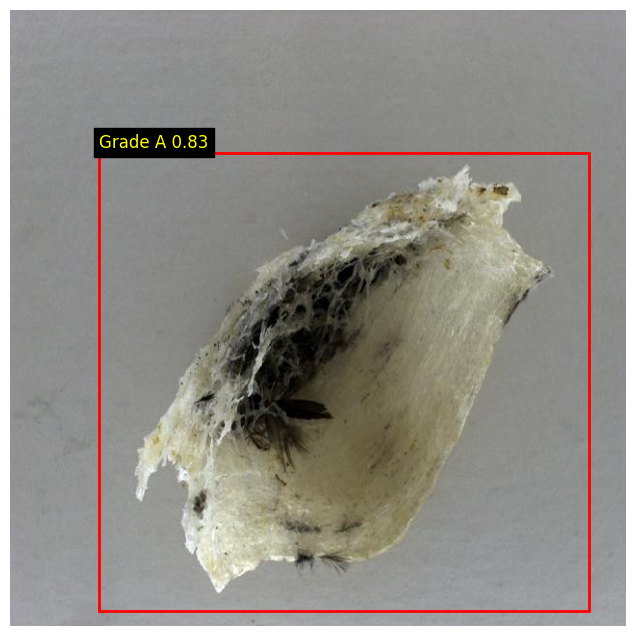

In [13]:
boxes, labels, scores = predict_image_frcnn(model, "/kaggle/working/BirdNest-4/test/LightFeather-1-_bmp.rf.e9318aedeb875e6a68d0d35be629d1b7.jpg", device)